In [1]:
%matplotlib inline
%run -i setupMatplotlib.py

In [2]:
import os

projectDir = os.environ['PLATO_PROJECT_HOME']
workDir = os.environ['PLATO_WORKDIR']

%run -i setupEnvironment.py

In [3]:
import numpy as np

In [4]:
from imp import reload
import simfile
reload(simfile)
from simfile import SimFile
import simulation
reload(simulation)
from simulation import Simulation

In [5]:
sim = Simulation("Run01", outputDir = workDir)
sim["PSF/Model"] = "MappedFromFileSymmetrical"
sim.run(removeOutputFile = True)
simFile = SimFile(workDir + '/Run01.hdf5')

### API of SimFile

Request image, bias and smearing maps
```
img = simFile.getImage(<Exposure Nr>)
biasMapLeft = simFile.getBiasMapLeft(<Exposure Nr>)
biasMapRight = simFile.getBiasMapRight(<Exposure Nr>)
smearingMap = simFile.getSmearingMap(<Exposure Nr>)

subPixelImage = simFile.getSubPixelImage(<Exposure Nr>)
```

Request smaller imagettes around a star position
```
im = simFile.getImagette(11632, 9, radius = 3)
```

Request star information
```
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()
ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(<Exposure Nr> [, minVmag=<Vmag>, maxVmag=<Vmag>])
```

Request Input Parameters
```
value = simFifle.getInputParameter(<groupName>, <parameterName>)
```

Request the Flatfield maps
```
prnu = simFile.getPRNU()
irnu = simFile.getIRNU()
```

Request the PSF
```
psf = simFile.getPsf("rebinnedPSFimage")
```

Request Platform information
```
RA, dec = simFile.getPlatformPointingCoordinates()
yaw, pitch, roll = simFile.getYawPitchRoll()
```

Reloading the HDF5 file
```
simFile.reload()
```

In [6]:
img0 = simFile.getImage(0)

In [7]:
bm0 = simFile.getBiasMapLeft(0)
sm0 = simFile.getSmearingMap(0)

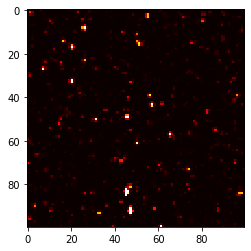

In [8]:
plt.imshow(img0, cmap=cm.hot)

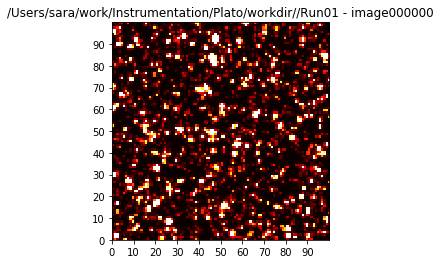

In [9]:
simFile.showImage(0)

In [10]:
#subPixelImage = simFile.getSubPixelImage(9)

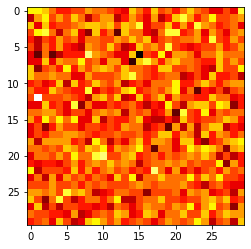

In [11]:
plt.imshow(bm0, interpolation='nearest', cmap=cm.hot)

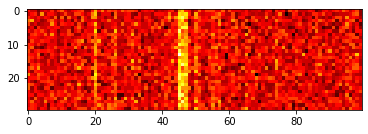

In [12]:
plt.imshow(sm0, interpolation='nearest', cmap=cm.hot)

In [13]:
starIDs = simFile.getStarCoordinates(9, minVmag = None, maxVmag = None)[0]
print(starIDs)

[ 4557  4559  4566 ... 13650 13654 13656]


In [14]:
imagette = simFile.getImagette(15563, 9, radius = 3)
#imagette = simFile.getImagette(11632, 9, radius = 3)

Error: SimfFile.getImagette(): star 15563 not in image image000009


TypeError: Image data of dtype object cannot be converted to float

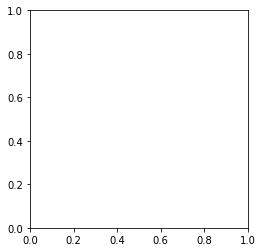

In [15]:
plt.imshow(imagette, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar()

In [ ]:
psf = simFile.getPsf("rebinnedPSFsubPixel")
plt.imshow(psf, interpolation='nearest', origin='lower', cmap=cm.hot)

In [ ]:
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()

In [ ]:
"starIDs[{}] = {}".format(len(starIDs), starIDs)

In [ ]:
print("RA[{}] = {}".format(len(RA), RA))
print("Dec[{}] = {}".format(len(dec), dec))
print("Vmag[{}] = {}".format(len(Vmag), Vmag))

In [ ]:
print("xFPmm[{}] = {}".format(len(xFPmm), xFPmm))
print("yFPmm[{}] = {}".format(len(yFPmm), yFPmm))

In [ ]:
print("rowPix[{}] = {}".format(len(rowPix), rowPix))
print("colPix[{}] = {}".format(len(colPix), colPix))

To get the coordinates of all stars within a magnitude range [minVmag, maxVmag] in image 10.

In [ ]:
starID, row, col, Xmm, Ymm, flux = simFile.getStarCoordinates(9, minVmag=6.0, maxVmag=12.0)

In [ ]:
"starID[{}] = {}".format(len(starID), starID)

In [ ]:
simFile.getInputParameter("ObservingParameters", "NumExposures")

In [ ]:
#%matplotlib qt
#%run -i setupMatplotlib.py

%matplotlib inline
%run -i setupMatplotlib.py

In [ ]:
#fig = simFile.showImage(9)
#ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(9)

#axis = fig.axes[0]
#axis.scatter(np.floor(col), np.floor(row), marker='x', c='g')

In [ ]:
fig, ax = plt.subplots()
image = simFile.getImage(9)
numRows = simFile.getInputParameter("SubField", "NumRows")
numColumns = simFile.getInputParameter("SubField", "NumColumns")
ax.imshow(image, cmap=cm.hot, interpolation="nearest", origin='lower', extent=[0, numRows, 0, numColumns])
ax.scatter(np.floor(col)+0.5, np.floor(row)+0.5, marker='x', c='g')

In [ ]:
prnu = simFile.getPRNU()
plt.imshow(prnu, interpolation='nearest', cmap=cm.hot)

In [ ]:
irnu = simFile.getIRNU()
plt.imshow(irnu, interpolation='nearest', cmap=cm.hot)

In [ ]:
RA, dec = simFile.getPlatformPointingCoordinates()
plt.scatter(RA, dec)

In [ ]:
yaw, pitch, roll = simFile.getYawPitchRoll()

In [ ]:
plt.plot(yaw, '-o')
plt.plot(pitch, '-o')
plt.plot(roll, '-o')